In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

In [2]:
df = sns.load_dataset('anscombe')

# Zapoznanie ze zbiorem danych

In [3]:
df.head(10)

,dataset,x,y
0,I,10.0,8.04
1,I,8.0,6.95
2,I,13.0,7.58
3,I,9.0,8.81
4,I,11.0,8.33
5,I,14.0,9.96
6,I,6.0,7.24
7,I,4.0,4.26
8,I,12.0,10.84
9,I,7.0,4.82


In [4]:
df.describe()

,x,y
count,44.000000,44.000000
mean,9.000000,7.500682
std,3.198837,1.958925
min,4.000000,3.100000
25%,7.000000,6.117500
50%,8.000000,7.520000
75%,11.000000,8.747500
max,19.000000,12.740000


In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
x,44.0,9.000000,3.198837,4.0,7.0000,8.00,11.0000,19.00
y,44.0,7.500682,1.958925,3.1,6.1175,7.52,8.7475,12.74


In [6]:
df.describe(include='all')

,dataset,x,y
count,44,44.000000,44.000000
unique,4,NaN,NaN
top,I,NaN,NaN
freq,11,NaN,NaN
mean,NaN,9.000000,7.500682
std,NaN,3.198837,1.958925
min,NaN,4.000000,3.100000
25%,NaN,7.000000,6.117500
50%,NaN,8.000000,7.520000
75%,NaN,11.000000,8.747500


In [7]:
df.isnull().sum()

dataset    0
x          0
y          0
dtype: int64

In [8]:
df.shape

(44, 3)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44 entries, 0 to 43
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   dataset  44 non-null     object 
 1   x        44 non-null     float64
 2   y        44 non-null     float64
dtypes: float64(2), object(1)
memory usage: 1.2+ KB


In [10]:
df.dtypes

dataset     object
x          float64
y          float64
dtype: object

In [11]:
df.columns.tolist()

['dataset', 'x', 'y']

In [12]:
df['dataset'].unique()

array(['I', 'II', 'III', 'IV'], dtype=object)

# Analiza statystyk opisowych czterech zbiorów danych (I, II, III, IV)

## Statystyki wszystkich czterech zbiorów danych wyglądają bardzo podobnie, a różnica między nimi jest minimalna w niektórych miejscach.

In [13]:
df.groupby('dataset').describe()

x                                               y            \
        count mean       std  min  25%  50%   75%   max count      mean   
dataset                                                                   
I        11.0  9.0  3.316625  4.0  6.5  9.0  11.5  14.0  11.0  7.500909   
II       11.0  9.0  3.316625  4.0  6.5  9.0  11.5  14.0  11.0  7.500909   
III      11.0  9.0  3.316625  4.0  6.5  9.0  11.5  14.0  11.0  7.500000   
IV       11.0  9.0  3.316625  8.0  8.0  8.0   8.0  19.0  11.0  7.500909   

                                                   
              std   min    25%   50%   75%    max  
dataset                                            
I        2.031568  4.26  6.315  7.58  8.57  10.84  
II       2.031657  3.10  6.695  8.14  8.95   9.26  
III      2.030424  5.39  6.250  7.11  7.98  12.74  
IV       2.030579  5.25  6.170  7.04  8.19  12.50

In [14]:
df.groupby('dataset').corr()

x         y
dataset                      
I       x  1.000000  0.816421
        y  0.816421  1.000000
II      x  1.000000  0.816237
        y  0.816237  1.000000
III     x  1.000000  0.816287
        y  0.816287  1.000000
IV      x  1.000000  0.816521
        y  0.816521  1.000000

# Regresja Liniowa

## Obliczanie Regresji Liniowej dla każdego datasetu w celu wyciągnięcia współczynnika nachylenia (a) i wyrazu wolnego (b) we wzorze: y = ax + b.

In [15]:
model_lin_reg_I = LinearRegression()
model_lin_reg_I.fit(df[df['dataset'] == 'I'][['x']], df[df['dataset'] == 'I']['y'])

LinearRegression()

In [16]:
print(f'Wzór funkcji liniowej dla datasetu I: y = {model_lin_reg_I.coef_[0]}*x + {model_lin_reg_I.intercept_}')

Wzór funkcji liniowej dla datasetu I: y = 0.5000909090909091*x + 3.0000909090909103


In [17]:
model_lin_reg_II = LinearRegression()
model_lin_reg_II.fit(df[df['dataset'] == 'II'][['x']], df[df['dataset'] == 'II']['y'])

LinearRegression()

In [18]:
print(f'Wzór funkcji liniowej dla datasetu II: y = {model_lin_reg_II.coef_[0]}*x + {model_lin_reg_II.intercept_}')

Wzór funkcji liniowej dla datasetu II: y = 0.5000000000000001*x + 3.000909090909089


In [19]:
model_lin_reg_III = LinearRegression()
model_lin_reg_III.fit(df[df['dataset'] == 'III'][['x']], df[df['dataset'] == 'III']['y'])

LinearRegression()

In [20]:
print(f'Wzór funkcji liniowej dla datasetu III: y = {model_lin_reg_III.coef_[0]}*x + {model_lin_reg_III.intercept_}')

Wzór funkcji liniowej dla datasetu III: y = 0.4997272727272728*x + 3.002454545454545


In [21]:
model_lin_reg_IV = LinearRegression()
model_lin_reg_IV.fit(df[df['dataset'] == 'IV'][['x']], df[df['dataset'] == 'IV']['y'])

LinearRegression()

In [22]:
print(f'Wzór funkcji liniowej dla datasetu IV: y = {model_lin_reg_IV.coef_[0]}*x + {model_lin_reg_IV.intercept_}')

Wzór funkcji liniowej dla datasetu IV: y = 0.4999090909090909*x + 3.0017272727272726


# Wykresy datasetów

## Wykresy datasetów mimo, że posiadają w przybliżeniu taki sam wzór: y = 0.5x + 3 to ich dane jak widać na wykresie są kompletnie inne. Ustawienie danych jako punktów w przypadku każdego zbioru danych jest inne, mimo takiego samego wzoru funkcji. Przykład ten pokazuje, że mimo podobnych statystyk i nawet w przybliżeniu takiego samego wzoru to dane są kompletnie inne. Dlatego przed budową modelu warto zwizualizować dane, ponieważ same statystyki mogą być mylące.

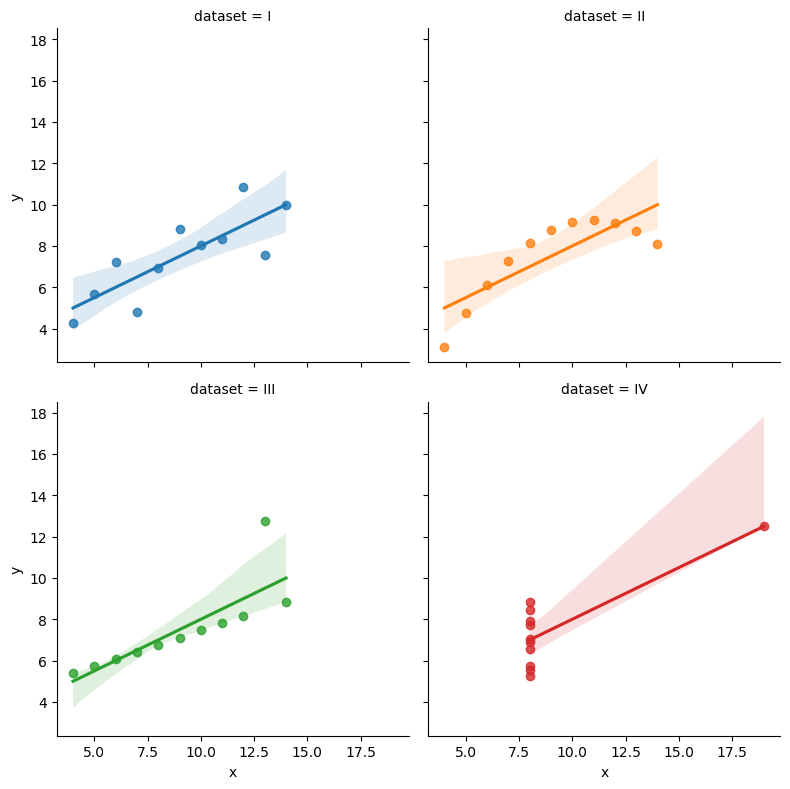

In [23]:
sns.lmplot(x='x', y='y', col='dataset', hue='dataset', data=df, col_wrap=2, height=4)
plt.show()